In [ ]:
# Устанавливаем необходимые библиотеки
!pip install ultralytics
!pip install gdown

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 871.7/871.7 kB 15.5 MB/s eta 0:00:00


In [ ]:
import gdown
import os
import shutil
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [ ]:
# Скачиваем датасет с Google Drive
url = 'https://drive.google.com/uc?id=1RdaqnGGlApWSYHnUqAK2Y9unZPVkQFPt'
output = 'dataset.zip'
gdown.download(url, output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1RdaqnGGlApWSYHnUqAK2Y9unZPVkQFPt
From (redirected): https://drive.google.com/uc?id=1RdaqnGGlApWSYHnUqAK2Y9unZPVkQFPt&confirm=t&uuid=39b7c63a-2252-4a8c-afd8-627c2d4f3af7
To: /content/dataset.zip
100%|██████████| 3.10G/3.10G [00:35<00:00, 86.3MB/s]


'dataset.zip'

In [ ]:
# Распаковываем архив
!unzip -q dataset.zip -d dataset

In [ ]:
# Путь к папке с изображениями и аннотациями
images_path = '/content/dataset/train_3/images'
labels_path = '/content/dataset/train_3/labels'

In [ ]:
# Создаем тренировочную и тестовую выборки
images = os.listdir(images_path)
train_images, test_images = train_test_split(images, test_size=0.05, random_state=42)

In [ ]:
# Создаем папки для тренировочной и тестовой выборок
os.makedirs('dataset/train/images', exist_ok=True)
os.makedirs('dataset/train/labels', exist_ok=True)
os.makedirs('dataset/val/images', exist_ok=True)
os.makedirs('dataset/val/labels', exist_ok=True)

In [ ]:
# Перемещаем файлы в соответствующие папки
for img in train_images:
    shutil.move(os.path.join(images_path, img), 'dataset/train/images')
    shutil.move(os.path.join(labels_path, img.replace('.jpg', '.txt')), 'dataset/train/labels')

for img in test_images:
    shutil.move(os.path.join(images_path, img), 'dataset/val/images')
    shutil.move(os.path.join(labels_path, img.replace('.jpg', '.txt')), 'dataset/val/labels')

In [ ]:
# Устанавливаем путь к конфигурационному файлу YOLOv8
config_path = 'yolov8_config.yaml'

In [ ]:
# Создаем конфигурационный файл для YOLOv8
with open(config_path, 'w') as f:
    f.write('''
    path: /content/dataset
    train: /content/dataset/train/images
    val: /content/dataset/val/images
    nc: 6
    names: ['TP0', 'FN1', 'YM2', 'MR3', 'SN4', 'MT5']
    ''')

In [ ]:
# Проверяем, что все файлы и папки существуют
assert os.path.exists('/content/dataset/train/images'), "Train images path does not exist"
assert os.path.exists('/content/dataset/train/labels'), "Train labels path does not exist"
assert os.path.exists('/content/dataset/val/images'), "Validation images path does not exist"
assert os.path.exists('/content/dataset/val/labels'), "Validation labels path does not exist"


In [ ]:
from PIL import Image
import os

def check_and_fix_images(directory):
    for filename in os.listdir(directory):
        if filename.endswith('.jpg') or filename.endswith('.jpeg') or filename.endswith('.png'):
            filepath = os.path.join(directory, filename)
            try:
                with Image.open(filepath) as img:
                    img.verify()  # Проверка целостности изображения
            except (IOError, SyntaxError) as e:
                print(f"Corrupt image file detected: {filepath}. Attempting to fix...")
                try:
                    with Image.open(filepath) as img:
                        img.load()  # Загрузка изображения
                    img.save(filepath)  # Сохранение исправленного изображения
                    print(f"Image file {filepath} has been fixed and saved.")
                except Exception as e:
                    print(f"Failed to fix image file: {filepath}. Error: {e}")

# Проверка и исправление изображений в тренировочной и валидационной выборках
check_and_fix_images('/content/dataset/train/images')
check_and_fix_images('/content/dataset/val/images')

print("Image integrity check and fix completed.")

Image integrity check and fix completed.


In [ ]:
# Импортируем библиотеку для обучения YOLOv8
from ultralytics import YOLO


In [ ]:
# Создаем модель YOLOv8
model = YOLO('/content/yolov8m.pt')


100%|██████████| 49.7M/49.7M [00:00<00:00, 226MB/s]


In [ ]:
# Создаем и обучаем модель YOLOv8

model.train(data=config_path, epochs=5, imgsz=640, batch=16, workers=8, project='runs/detect', name='train', exist_ok=True)



Ultralytics YOLOv8.2.89 🚀 Python-3.10.12 torch-2.4.0+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=/content/yolov8m.pt, data=yolov8_config.yaml, epochs=5, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=runs/detect, name=train, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True,

100%|██████████| 755k/755k [00:00<00:00, 18.3MB/s]


Overriding model.yaml nc=80 with nc=6

                   from  n    params  module                                       arguments                     
  0                  -1  1      1392  ultralytics.nn.modules.conv.Conv             [3, 48, 3, 2]                 
  1                  -1  1     41664  ultralytics.nn.modules.conv.Conv             [48, 96, 3, 2]                
  2                  -1  2    111360  ultralytics.nn.modules.block.C2f             [96, 96, 2, True]             
  3                  -1  1    166272  ultralytics.nn.modules.conv.Conv             [96, 192, 3, 2]               
  4                  -1  4    813312  ultralytics.nn.modules.block.C2f             [192, 192, 4, True]           
  5                  -1  1    664320  ultralytics.nn.modules.conv.Conv             [192, 384, 3, 2]              
  6                  -1  4   3248640  ultralytics.nn.modules.block.C2f             [384, 384, 4, True]           
  7                  -1  1   1991808  ultralytics

100%|██████████| 6.25M/6.25M [00:00<00:00, 106MB/s]


AMP: checks passed ✅


...

                   all         84        533      0.802      0.742      0.824      0.529



5 epochs completed in 0.280 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 52.0MB
Optimizer stripped from runs/detect/train/weights/best.pt, 52.0MB

Validating runs/detect/train/weights/best.pt...
Ultralytics YOLOv8.2.89 🚀 Python-3.10.12 torch-2.4.0+cu121 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 218 layers, 25,843,234 parameters, 0 gradients, 78.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:03<00:00,  1.29s/it]


                   all         84        533      0.761      0.771      0.823       0.53
                   TP0         84         85      0.779      0.869      0.892      0.612
                   FN1         83         83      0.865      0.775      0.879      0.518
                   YM2         81         82      0.818      0.493      0.654      0.275
                   MR3         82         82      0.675      0.939      0.897       0.61
                   SN4         64        119      0.596      0.622      0.696      0.392
                   MT5         82         82       0.83      0.927      0.923      0.772
Speed: 0.3ms preprocess, 10.5ms inference, 0.0ms loss, 5.3ms postprocess per image
Results saved to runs/detect/train


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e144b5aefe0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

In [ ]:
# Обучение с callback для сохранение весов на гугл- диск
from google.colab import drive
import shutil
import os
from ultralytics import YOLO

# Монтируем Google Диск
drive.mount('/content/drive')

# Путь к директории на Google Диске, куда будут сохраняться веса
google_drive_weights_dir = '/content/drive/MyDrive/yolov8_weights'

# Убедитесь, что директория существует
os.makedirs(google_drive_weights_dir, exist_ok=True)

# Путь к директории, где YOLOv8 сохраняет веса
yolov8_weights_dir = 'runs/detect/train/weights'

# Проверяем наличие лучших весов на Google Диске
best_weights_path = os.path.join(google_drive_weights_dir, 'best.pt')
if os.path.exists(best_weights_path):
    print("Best weights found on Google Drive. Loading them for training.")
    model = YOLO(best_weights_path)
else:
    print("No best weights found on Google Drive. Using default weights.")
    model = YOLO('yolov8m.pt')

# Обучение модели YOLOv8
model.train(data=config_path, epochs=5, imgsz=640, batch=16, workers=8, project='runs/detect', name='train', exist_ok=True)

# Копирование весов на Google Диск после завершения обучения
for file_name in os.listdir(yolov8_weights_dir):
    full_file_name = os.path.join(yolov8_weights_dir, file_name)
    if os.path.isfile(full_file_name):
        shutil.copy(full_file_name, google_drive_weights_dir)
print("Weights copied to Google Drive after training.")

print("Обучение завершено и веса сохранены на Google Диск.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
No best weights found on Google Drive. Using default weights.
Ultralytics YOLOv8.2.89 🚀 Python-3.10.12 torch-2.4.0+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=yolov8m.pt, data=yolov8_config.yaml, epochs=5, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=runs/detect, name=train, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False

100%|██████████| 755k/755k [00:00<00:00, 14.5MB/s]


Overriding model.yaml nc=80 with nc=6

                   from  n    params  module                                       arguments                     
  0                  -1  1      1392  ultralytics.nn.modules.conv.Conv             [3, 48, 3, 2]                 
  1                  -1  1     41664  ultralytics.nn.modules.conv.Conv             [48, 96, 3, 2]                
  2                  -1  2    111360  ultralytics.nn.modules.block.C2f             [96, 96, 2, True]             
  3                  -1  1    166272  ultralytics.nn.modules.conv.Conv             [96, 192, 3, 2]               
  4                  -1  4    813312  ultralytics.nn.modules.block.C2f             [192, 192, 4, True]           
  5                  -1  1    664320  ultralytics.nn.modules.conv.Conv             [192, 384, 3, 2]              
  6                  -1  4   3248640  ultralytics.nn.modules.block.C2f             [384, 384, 4, True]           
  7                  -1  1   1991808  ultralytics

100%|██████████| 6.25M/6.25M [00:00<00:00, 74.9MB/s]


AMP: checks passed ✅


...

        5/5      6.95G      1.095     0.8656      1.159        175        640: 100%|██████████| 49/49 [03:34<00:00,  4.37s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:01<00:00,  1.48it/s]

                   all         42        267      0.834      0.745      0.829      0.528



5 epochs completed in 0.310 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 52.0MB
Optimizer stripped from runs/detect/train/weights/best.pt, 52.0MB

Validating runs/detect/train/weights/best.pt...
Ultralytics YOLOv8.2.89 🚀 Python-3.10.12 torch-2.4.0+cu121 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 218 layers, 25,843,234 parameters, 0 gradients, 78.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:02<00:00,  1.02s/it]


                   all         42        267      0.833      0.745      0.829       0.53
                   TP0         42         43       0.78      0.767      0.793      0.522
                   FN1         41         41          1      0.754      0.927      0.525
                   YM2         40         41      0.861      0.452      0.661      0.315
                   MR3         41         41      0.829      0.927      0.949      0.642
                   SN4         32         60      0.681      0.641      0.728      0.422
                   MT5         41         41       0.85      0.927      0.917      0.755
Speed: 0.2ms preprocess, 11.0ms inference, 0.0ms loss, 5.7ms postprocess per image
Results saved to runs/detect/train
Weights copied to Google Drive after training.
Обучение завершено и веса сохранены на Google Диск.


In [ ]:
# # Настройка параметров обучения
# training_params = {
#     'data': '/content/yolov8_config.yaml',  # путь к вашему датасету
#     'epochs': 5,  # количество эпох
#     'batch_size': 16,  # размер батча
#     'img_size': 640,  # размер изображения
#     'name': 'train',  # имя эксперимента
#     'project': 'runs/detect',  # директория для сохранения результатов
#     'exist_ok': True,  # перезаписывать существующие результаты
#     'pretrained': True,  # использовать предобученные веса
#     'optimizer': 'auto',  # оптимизатор
#     'verbose': True,  # выводить подробную информацию
#     'seed': 0,  # начальное значение для генератора случайных чисел
#     'deterministic': True,  # детерминированные результаты
#     'single_cls': False,  # использовать один класс
#     'rect': False,  # прямоугольные изображения
#     'cos_lr': False,  # косинусное изменение скорости обучения
#     'close_mosaic': 10,  # закрыть мозаичное обучение
#     'resume': False,  # возобновить обучение
#     'amp': True,  # автоматическая смешанная точность
#     'fraction': 1.0,  # доля данных для обучения
#     'profile': False,  # профилирование
#     'freeze': None,  # заморозить слои
#     'multi_scale': False,  # мульти-масштабное обучение
#     'overlap_mask': True,  # перекрывающиеся маски
#     'mask_ratio': 4,  # соотношение масок
#     'dropout': 0.0,  # вероятность дропаута
#     'val': True,  # валидация
#     'split': 'val',  # разделение данных
#     'save_json': False,  # сохранить результаты в формате JSON
#     'save_hybrid': False,  # сохранить гибридные результаты
#     'conf': None,  # порог уверенности
#     'iou': 0.7,  # порог IoU
#     'max_det': 300,  # максимальное количество детекций
#     'half': False,  # использовать половинную точность
#     'dnn': False,  # использовать DNN
#     'plots': True,  # строить графики
#     'source': None,  # источник данных
#     'vid_stride': 1,  # шаг видео
#     'stream_buffer': False,  # буфер потока
#     'visualize': False,  # визуализация
#     'augment': False,  # аугментация
#     'agnostic_nms': False,  # агностическое NMS
#     'classes': None,  # классы
#     'retina_masks': False,  # маски сетчатки
#     'embed': None,  # встраивание
#     'show': False,  # показать результаты
#     'save_frames': False,  # сохранить кадры
#     'save_txt': False,  # сохранить результаты в формате TXT
#     'save_conf': False,  # сохранить уверенность
#     'save_crop': False,  # сохранить обрезанные изображения
#     'show_labels': True,  # показать метки
#     'show_conf': True,  # показать уверенность
#     'show_boxes': True,  # показать боксы
#     'line_width': None,  # ширина линии
#     'format': 'torchscript',  # формат
#     'keras': False,  # использовать Keras
#     'optimize': False,  # оптимизация
#     'int8': False,  # использовать int8
#     'dynamic': False,  # динамическое изменение
#     'simplify': False,  # упрощение
#     'opset': None,  # версия ONNX
#     'workspace': 4,  # рабочее пространство
#     'nms': False,  # NMS
#     'lr0': 0.01,  # начальная скорость обучения
#     'lrf': 0.01,  # конечная скорость обучения
#     'momentum': 0.937,  # момент
#     'weight_decay': 0.0005,  # весовое затухание
#     'warmup_epochs': 3.0,  # количество эпох разогрева
#     'warmup_momentum': 0.8,  # момент разогрева
#     'warmup_bias_lr': 0.1,  # скорость обучения смещения разогрева
#     'box': 7.5,  # вес бокса
#     'cls': 0.5,  # вес класса
#     'dfl': 1.5,  # вес DFL
#     'pose': 12.0,  # вес позы
#     'kobj': 1.0,  # вес объекта
#     'label_smoothing': 0.0,  # сглаживание меток
#     'nbs': 64,  # размер батча
#     'hsv_h': 0.015,  # изменение оттенка HSV
#     'hsv_s': 0.7,  # изменение насыщенности HSV
#     'hsv_v': 0.4,  # изменение яркости HSV
#     'degrees': 0.0,  # градусы
#     'translate': 0.1,  # перевод
#     'scale': 0.5,  # масштаб
#     'shear': 0.0,  # сдвиг
#     'perspective': 0.0,  # перспектива
#     'flipud': 0.0,  # переворот по вертикали
#     'fliplr': 0.5,  # переворот по горизонтали
#     'bgr': 0.0,  # BGR
#     'mosaic': 1.0,  # мозаика
#     'mixup': 0.0,  # миксап
#     'copy_paste': 0.0,  # копирование и вставка
#     'auto_augment': 'randaugment',  # автоматическая аугментация
#     'erasing': 0.4,  # стирание
#     'crop_fraction': 1.0,  # доля обрезки
#     'cfg': None,  # конфигурация
#     'tracker': 'botsort.yaml',  # трекер
#     'save_dir': 'runs/detect/train'  # директория для сохранения
# }

# # Запуск обучения
# model.train(**training_params)

In [ ]:
# С Тюнингом гиперпараметров
# import optuna
# from ultralytics import YOLO

# # Функция для обучения модели с заданными гиперпараметрами
# def objective(trial):
#     # Определение гиперпараметров для тюнинга
#     lr0 = trial.suggest_loguniform('lr0', 1e-5, 1e-1)
#     momentum = trial.suggest_uniform('momentum', 0.8, 0.99)
#     weight_decay = trial.suggest_loguniform('weight_decay', 1e-6, 1e-3)
#     batch_size = trial.suggest_categorical('batch_size', [8, 16, 32])
#     epochs = trial.suggest_int('epochs', 10, 50)

#     # Создаем модель YOLOv8
#     model = YOLO('/content/yolov8m.pt')

#     # Настройка параметров обучения
#     training_params = {
#         'data': '/content/yolov8_config.yaml',
#         'epochs': epochs,
#         'batch_size': batch_size,
#         'img_size': 640,
#         'name': 'train',
#         'project': 'runs/detect',
#         'exist_ok': True,
#         'pretrained': True,
#         'optimizer': 'SGD',
#         'verbose': True,
#         'seed': 0,
#         'deterministic': True,
#         'single_cls': False,
#         'rect': False,
#         'cos_lr': True,
#         'close_mosaic': 10,
#         'resume': False,
#         'amp': True,
#         'fraction': 1.0,
#         'profile': False,
#         'freeze': None,
#         'multi_scale': True,
#         'overlap_mask': True,
#         'mask_ratio': 4,
#         'dropout': 0.0,
#         'val': True,
#         'split': 'val',
#         'save_json': False,
#         'save_hybrid': False,
#         'conf': 0.25,
#         'iou': 0.45,
#         'max_det': 300,
#         'half': False,
#         'dnn': False,
#         'plots': True,
#         'source': None,
#         'vid_stride': 1,
#         'stream_buffer': False,
#         'visualize': False,
#         'augment': True,
#         'agnostic_nms': False,
#         'classes': None,
#         'retina_masks': False,
#         'embed': None,
#         'show': False,
#         'save_frames': False,
#         'save_txt': False,
#         'save_conf': False,
#         'save_crop': False,
#         'show_labels': True,
#         'show_conf': True,
#         'show_boxes': True,
#         'line_width': None,
#         'format': 'torchscript',
#         'keras': False,
#         'optimize': False,
#         'int8': False,
#         'dynamic': False,
#         'simplify': False,
#         'opset': None,
#         'workspace': 4,
#         'nms': False,
#         'lr0': lr0,
#         'momentum': momentum,
#         'weight_decay': weight_decay,
#         'warmup_epochs': 3.0,
#         'warmup_momentum': 0.8,
#         'warmup_bias_lr': 0.1,
#         'box': 7.5,
#         'cls': 0.5,
#         'dfl': 1.5,
#         'pose': 12.0,
#         'kobj': 1.0,
#         'label_smoothing': 0.0,
#         'nbs': 64,
#         'hsv_h': 0.015,
#         'hsv_s': 0.7,
#         'hsv_v': 0.4,
#         'degrees': 0.0,
#         'translate': 0.1,
#         'scale': 0.5,
#         'shear': 0.0,
#         'perspective': 0.0,
#         'flipud': 0.0,
#         'fliplr': 0.5,
#         'bgr': 0.0,
#         'mosaic': 1.0,
#         'mixup': 0.0,
#         'copy_paste': 0.0,
#         'auto_augment': 'randaugment',
#         'erasing': 0.4,
#         'crop_fraction': 1.0,
#         'cfg': None,
#         'tracker': 'botsort.yaml',
#         'save_dir': 'runs/detect/train'
#     }

#     # Запуск обучения
#     model.train(**training_params)

#     # Возвращаем метрику для оптимизации (например, точность)
#     results = model.val()
#     return results['metrics/mAP_0.5']

# # Создание и запуск исследования Optuna
# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=50)

# # Вывод лучших гиперпараметров
# print("Best hyperparameters: ", study.best_params)

In [ ]:
# Оцениваем модель
metrics = model.val()

Ultralytics YOLOv8.2.89 🚀 Python-3.10.12 torch-2.4.0+cu121 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 218 layers, 25,843,234 parameters, 0 gradients, 78.7 GFLOPs


val: Scanning /content/dataset/val/labels.cache... 42 images, 0 backgrounds, 0 corrupt: 100%|██████████| 42/42 [00:00<?, ?it/s]

val: WARNING ⚠️ /content/dataset/val/images/1040-581.jpg: corrupt JPEG restored and saved
val: WARNING ⚠️ /content/dataset/val/images/1113-583.jpg: corrupt JPEG restored and saved
val: WARNING ⚠️ /content/dataset/val/images/2562-1627.jpg: corrupt JPEG restored and saved
val: WARNING ⚠️ /content/dataset/val/images/2596-1647.jpg: corrupt JPEG restored and saved
val: WARNING ⚠️ /content/dataset/val/images/2598-1649.jpg: corrupt JPEG restored and saved
val: WARNING ⚠️ /content/dataset/val/images/2601-1653.jpg: corrupt JPEG restored and saved
val: WARNING ⚠️ /content/dataset/val/images/3184-1706.jpg: corrupt JPEG restored and saved
val: WARNING ⚠️ /content/dataset/val/images/3220-1713.jpg: corrupt JPEG restored and saved
val: WARNING ⚠️ /content/dataset/val/images/3662-1869.jpg: corrupt JPEG restored and saved
val: WARNING ⚠️ /content/dataset/val/images/4254-2021.jpg: corrupt JPEG restored and saved
val: WARNING ⚠️ /content/dataset/val/images/4923-2173.jpg: corrupt JPEG restored and saved
v


/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:25<00:00,  8.54s/it]


                   all         42        267      0.831      0.747      0.828      0.531
                   TP0         42         43      0.781      0.767      0.794      0.521
                   FN1         41         41          1      0.755      0.928      0.535
                   YM2         40         41      0.861      0.455       0.65      0.315
                   MR3         41         41      0.808      0.927      0.949      0.635
                   SN4         32         60      0.683       0.65      0.723      0.418
                   MT5         41         41       0.85      0.927      0.926      0.764
Speed: 0.9ms preprocess, 33.3ms inference, 0.0ms loss, 4.7ms postprocess per image
Results saved to runs/detect/train


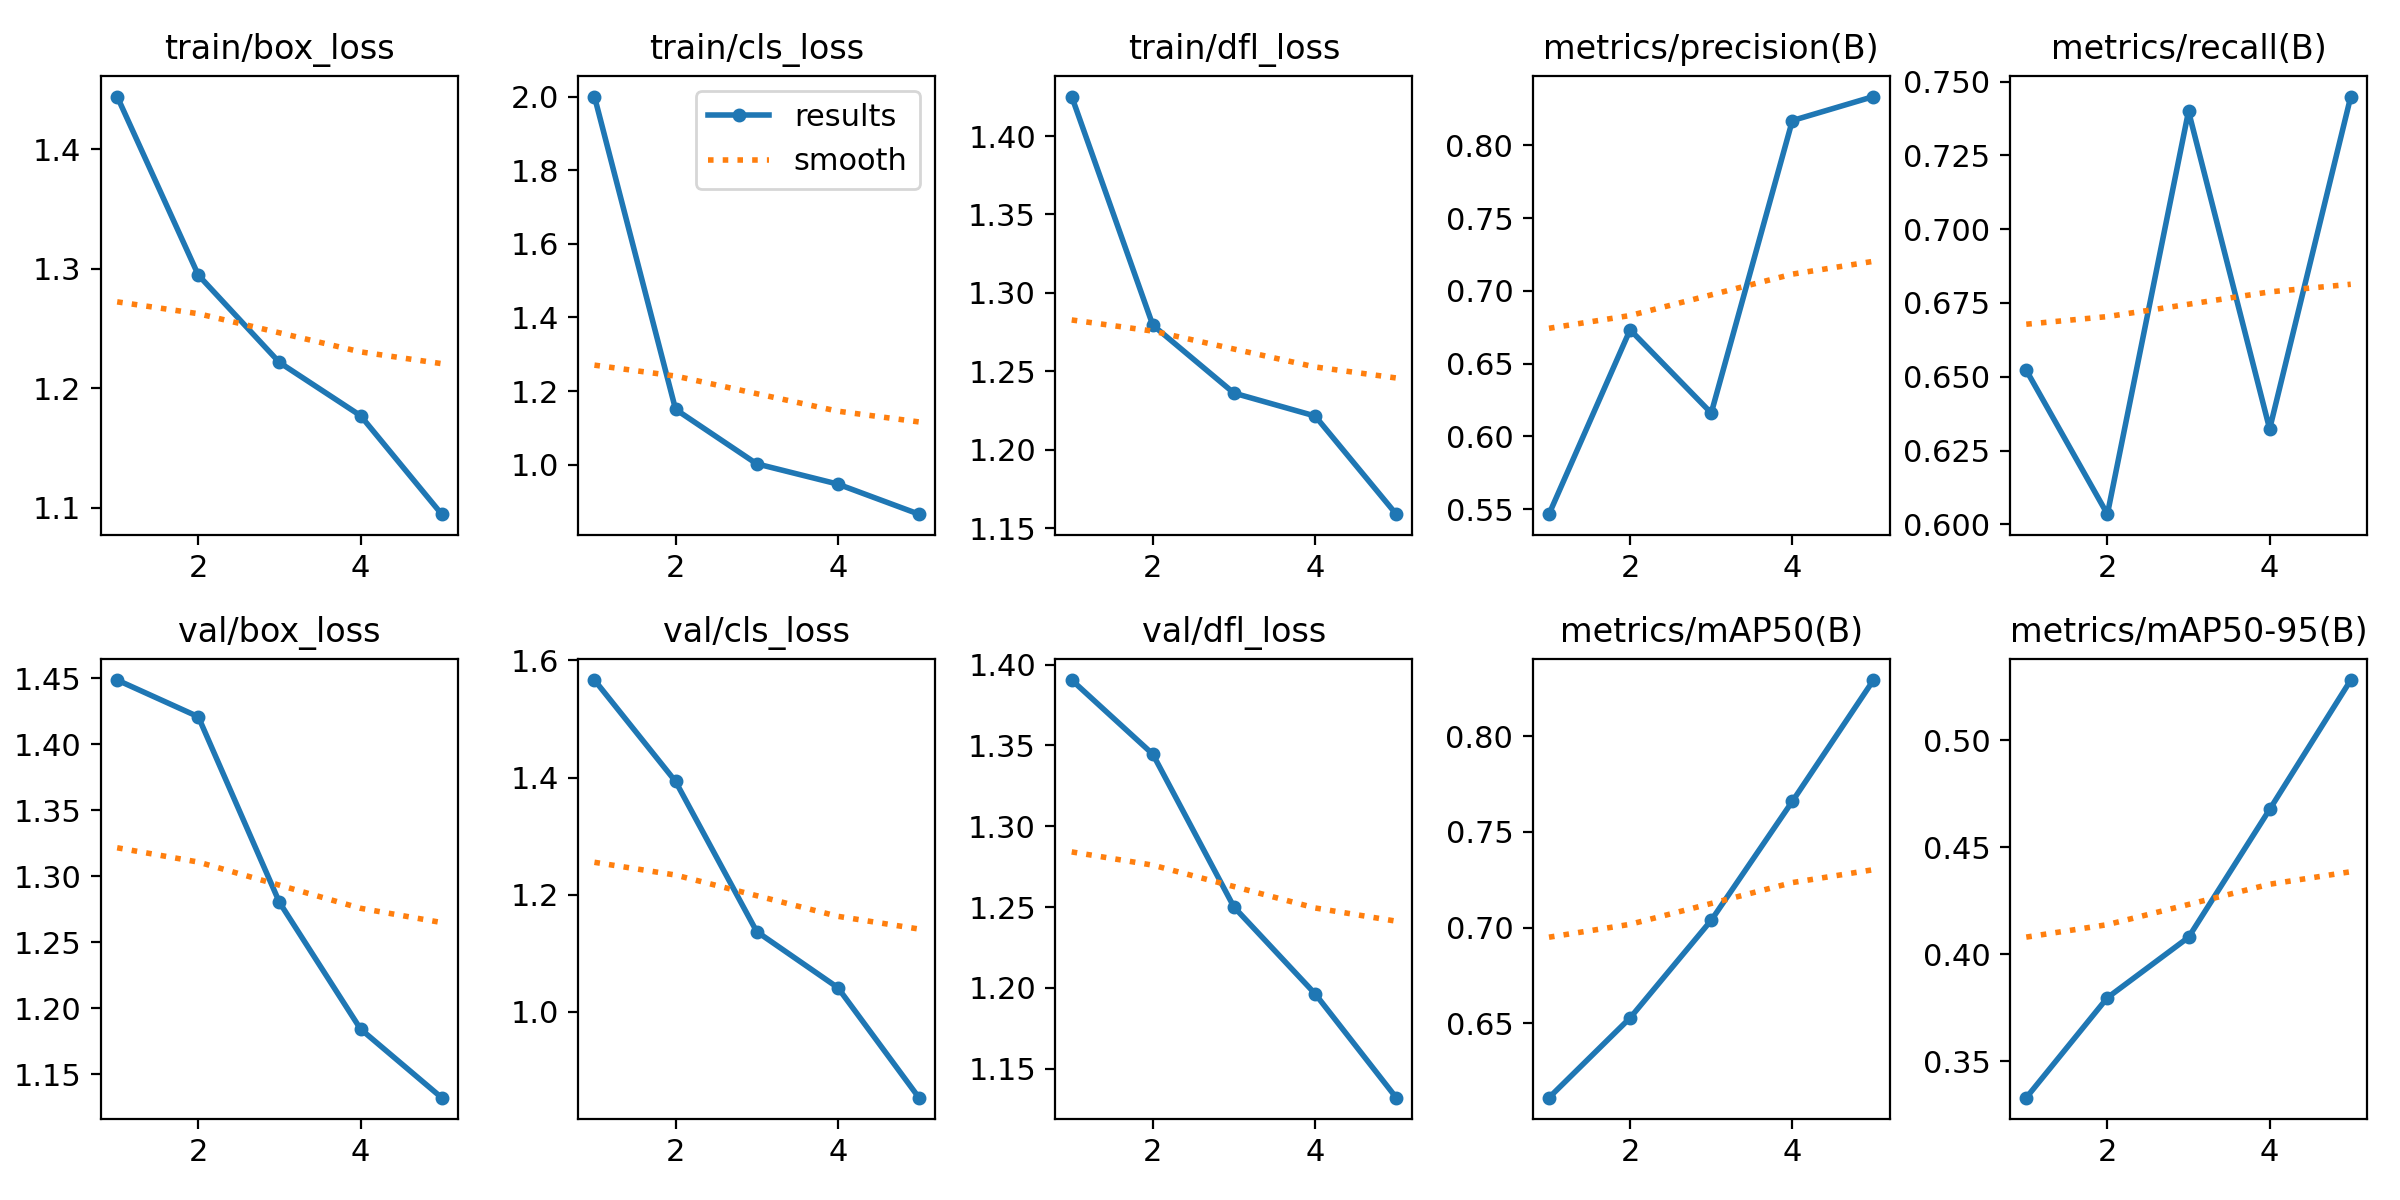

In [ ]:
from IPython.display import Image, display

# Путь к директории с результатами
save_dir = 'runs/detect/train'

# Отображение графиков
display(Image(filename=f'{save_dir}/results.png'))

In [ ]:
# Очистка памяти
import gc
import torch
gc.collect()
torch.cuda.empty_cache()

In [ ]:
# Выполняем предсказания на тестовых данных
results = model.predict(source='/content/dataset/val/images', save=True)


image 1/42 /content/dataset/val/images/1040-581.jpg: 640x480 1 TP0, 2 MR3s, 3 SN4s, 5 MT5s, 80.3ms
image 2/42 /content/dataset/val/images/1113-583.jpg: 640x480 2 TP0s, 1 FN1, 1 MR3, 1 MT5, 27.8ms
image 3/42 /content/dataset/val/images/1689-890.jpg: 640x480 2 TP0s, 2 FN1s, 1 MR3, 2 SN4s, 1 MT5, 27.7ms
image 4/42 /content/dataset/val/images/1705-956.jpg: 640x480 3 TP0s, 1 FN1, 1 MR3, 3 SN4s, 1 MT5, 27.7ms
image 5/42 /content/dataset/val/images/1719-967.jpg: 640x480 1 TP0, 1 FN1, 1 YM2, 1 MR3, 5 SN4s, 1 MT5, 27.7ms
image 6/42 /content/dataset/val/images/1720-969.jpg: 640x480 1 TP0, 1 FN1, 1 YM2, 2 MR3s, 3 SN4s, 1 MT5, 27.7ms
image 7/42 /content/dataset/val/images/1724-978.jpg: 640x480 1 TP0, 1 FN1, 1 YM2, 2 MR3s, 3 SN4s, 1 MT5, 27.7ms
image 8/42 /content/dataset/val/images/1769-1043.jpg: 640x480 1 TP0, 1 FN1, 1 YM2, 2 MR3s, 4 SN4s, 1 MT5, 27.9ms
image 9/42 /content/dataset/val/images/1942-1204.jpg: 640x480 1 TP0, 1 FN1, 1 YM2, 2 MR3s, 3 SN4s, 1 MT5, 27.8ms
image 10/42 /content/dataset/va

In [ ]:
# Очистка памяти
gc.collect()
torch.cuda.empty_cache()

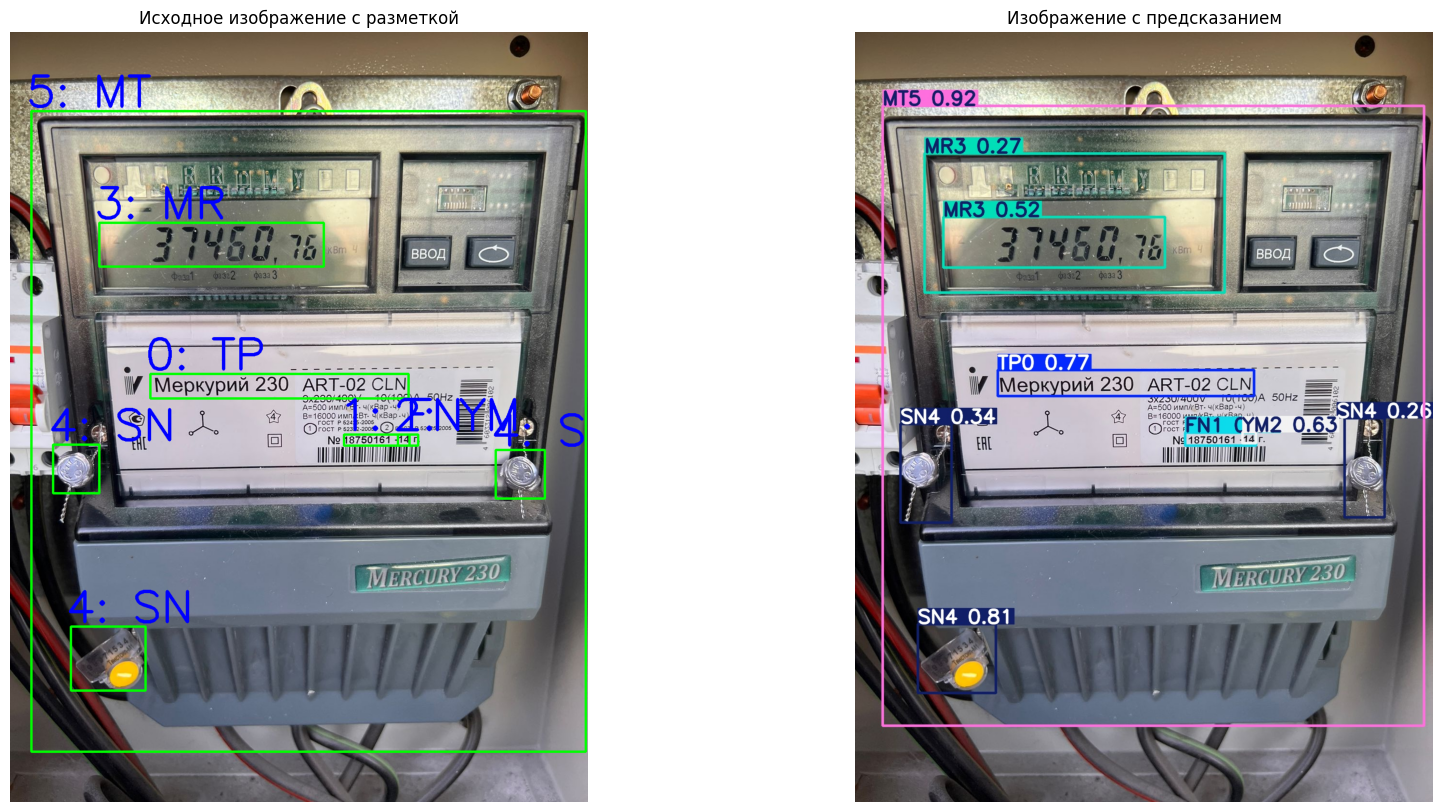

FileNotFoundError: [Errno 2] No such file or directory: 'runs/detect/train/1720-969.txt'

In [ ]:
import gc
import torch
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Список имен классов по индексам
class_names = ['TP', 'FN', 'YM', 'MR', 'SN', 'MT']

def read_labels(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()
    labels = []
    for idx, line in enumerate(lines):
        parts = line.strip().split()
        class_id = int(parts[0])  # Числовое значение класса
        points = [float(p) for p in parts[1:]]  # Координаты
        labels.append((class_id, points, idx))  # Добавляем индекс строки
    return labels

def draw_boxes(image, labels, color=(0, 255, 0)):
    h, w, _ = image.shape
    for class_id, points, idx in labels:
        # Преобразуем координаты из относительных в абсолютные
        pts = [(int(points[i] * w), int(points[i+1] * h)) for i in range(0, len(points), 2)]
        pts = np.array(pts, np.int32)
        pts = pts.reshape((-1, 1, 2))

        # Нарисовать полигон (четырехугольник) по точкам
        cv2.polylines(image, [pts], isClosed=True, color=color, thickness=4)

        # Найти верхний левый угол полигона
        top_left_x = np.min(pts[:, 0, 0])
        top_left_y = np.min(pts[:, 0, 1])

        # Получить имя класса на основе его id
        class_name = class_names[class_id]

        # Отображение имени класса снаружи верхнего левого угла
        text = f"{class_id}: {class_name}"  # Добавляем id и имя класса

        text_x = top_left_x - 10  # Смещение текста влево от полигона
        text_y = top_left_y - 10  # Смещение текста выше полигона
        cv2.putText(image, text, (text_x, text_y), cv2.FONT_HERSHEY_SIMPLEX, 3.0, (255, 0, 0), 5)  # Увеличен шрифт до 3.0, толщина до 5
    return image

def calculate_iou(box1, box2):
    # Преобразуем координаты из относительных в абсолютные
    box1 = np.array(box1).reshape(-1, 2)
    box2 = np.array(box2).reshape(-1, 2)

    # Найти координаты пересечения
    xA = max(box1[:, 0].min(), box2[:, 0].min())
    yA = max(box1[:, 1].min(), box2[:, 1].min())
    xB = min(box1[:, 0].max(), box2[:, 0].max())
    yB = min(box1[:, 1].max(), box2[:, 1].max())

    # Вычислить площадь пересечения
    interArea = max(0, xB - xA + 1) * max(0, yB - yA + 1)

    # Вычислить площади обоих прямоугольников
    box1Area = (box1[:, 0].max() - box1[:, 0].min() + 1) * (box1[:, 1].max() - box1[:, 1].min() + 1)
    box2Area = (box2[:, 0].max() - box2[:, 0].min() + 1) * (box2[:, 1].max() - box2[:, 1].min() + 1)

    # Вычислить IoU
    iou = interArea / float(box1Area + box2Area - interArea)
    return iou

def visualize_images_with_boxes(images_path, labels_path, results_path):
    image_files = [f for f in os.listdir(images_path) if f.endswith('.jpg')]
    iou_scores = []

    for image_file in image_files:
        image_path = os.path.join(images_path, image_file)
        label_file = image_file.replace('.jpg', '.txt')
        label_path = os.path.join(labels_path, label_file)
        result_image_path = os.path.join(results_path, image_file)

        if os.path.exists(label_path) and os.path.exists(result_image_path):
            # Загружаем исходное изображение и аннотации
            original_image = cv2.imread(image_path)
            labels = read_labels(label_path)
            original_image_with_boxes = draw_boxes(original_image.copy(), labels, color=(0, 255, 0))

            # Загружаем изображение с предсказанием
            pred_image = cv2.imread(result_image_path)

            # Convert BGR image to RGB for displaying with matplotlib
            original_image_with_boxes = cv2.cvtColor(original_image_with_boxes, cv2.COLOR_BGR2RGB)
            pred_image = cv2.cvtColor(pred_image, cv2.COLOR_BGR2RGB)

            # Отображаем изображения рядом друг с другом
            fig, axes = plt.subplots(1, 2, figsize=(20, 10))
            axes[0].imshow(original_image_with_boxes)
            axes[0].set_title('Исходное изображение с разметкой')
            axes[0].axis('off')

            axes[1].imshow(pred_image)
            axes[1].set_title('Изображение с предсказанием')
            axes[1].axis('off')

            plt.show()

            # Чтение предсказанных меток
            pred_labels = read_labels(result_image_path.replace('.jpg', '.txt'))

            # Вычисление IoU для каждой пары предсказание-оригинал
            for orig_label in labels:
                orig_class_id, orig_points, _ = orig_label
                for pred_label in pred_labels:
                    pred_class_id, pred_points, _ = pred_label
                    if orig_class_id == pred_class_id:
                        iou = calculate_iou(orig_points, pred_points)
                        iou_scores.append(iou)

    # Вычисление среднего значения IoU
    mean_iou = np.mean(iou_scores) if iou_scores else 0
    print(f"Среднее значение IoU: {mean_iou:.4f}")

# Путь к сохраненным результатам
results_dir = 'runs/detect/train'
# Путь к исходным изображениям и разметке
val_images_dir = '/content/dataset/val/images'
val_labels_dir = '/content/dataset/val/labels'

# Визуализируем результаты
visualize_images_with_boxes(val_images_dir, val_labels_dir, results_dir)

# Очистка памяти
gc.collect()
torch.cuda.empty_cache()

print("Обучение и оценка модели завершены.")

In [ ]:
import gc
import torch
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Список имен классов по индексам
class_names = ['TP', 'FN', 'YM', 'MR', 'SN', 'MT']

def read_labels(file_path):
    if not os.path.exists(file_path):
        print(f"File not found: {file_path}")
        return []

    with open(file_path, 'r') as file:
        lines = file.readlines()
    labels = []
    for idx, line in enumerate(lines):
        parts = line.strip().split()
        class_id = int(parts[0])  # Числовое значение класса
        points = [float(p) for p in parts[1:]]  # Координаты
        labels.append((class_id, points, idx))  # Добавляем индекс строки
    return labels

def draw_boxes(image, labels, color=(0, 255, 0)):
    h, w, _ = image.shape
    for class_id, points, idx in labels:
        # Преобразуем координаты из относительных в абсолютные
        pts = [(int(points[i] * w), int(points[i+1] * h)) for i in range(0, len(points), 2)]
        pts = np.array(pts, np.int32)
        pts = pts.reshape((-1, 1, 2))

        # Нарисовать полигон (четырехугольник) по точкам
        cv2.polylines(image, [pts], isClosed=True, color=color, thickness=4)

        # Найти верхний левый угол полигона
        top_left_x = np.min(pts[:, 0, 0])
        top_left_y = np.min(pts[:, 0, 1])

        # Получить имя класса на основе его id
        class_name = class_names[class_id]

        # Отображение имени класса снаружи верхнего левого угла
        text = f"{class_id}: {class_name}"  # Добавляем id и имя класса

        text_x = top_left_x - 10  # Смещение текста влево от полигона
        text_y = top_left_y - 10  # Смещение текста выше полигона
        cv2.putText(image, text, (text_x, text_y), cv2.FONT_HERSHEY_SIMPLEX, 3.0, (255, 0, 0), 5)  # Увеличен шрифт до 3.0, толщина до 5
    return image

def calculate_iou(box1, box2):
    # Преобразуем координаты из относительных в абсолютные
    box1 = np.array(box1).reshape(-1, 2)
    box2 = np.array(box2).reshape(-1, 2)

    # Найти координаты пересечения
    xA = max(box1[:, 0].min(), box2[:, 0].min())
    yA = max(box1[:, 1].min(), box2[:, 1].min())
    xB = min(box1[:, 0].max(), box2[:, 0].max())
    yB = min(box1[:, 1].max(), box2[:, 1].max())

    # Вычислить площадь пересечения
    interArea = max(0, xB - xA + 1) * max(0, yB - yA + 1)

    # Вычислить площади обоих прямоугольников
    box1Area = (box1[:, 0].max() - box1[:, 0].min() + 1) * (box1[:, 1].max() - box1[:, 1].min() + 1)
    box2Area = (box2[:, 0].max() - box2[:, 0].min() + 1) * (box2[:, 1].max() - box2[:, 1].min() + 1)

    # Вычислить IoU
    iou = interArea / float(box1Area + box2Area - interArea)
    return iou

def visualize_images_with_boxes(images_path, labels_path, results_path):
    image_files = [f for f in os.listdir(images_path) if f.endswith('.jpg')]
    iou_scores = []

    for image_file in image_files:
        image_path = os.path.join(images_path, image_file)
        label_file = image_file.replace('.jpg', '.txt')
        label_path = os.path.join(labels_path, label_file)
        result_image_path = os.path.join(results_path, image_file)

        if os.path.exists(label_path) and os.path.exists(result_image_path):
            # Загружаем исходное изображение и аннотации
            original_image = cv2.imread(image_path)
            labels = read_labels(label_path)
            original_image_with_boxes = draw_boxes(original_image.copy(), labels, color=(0, 255, 0))

            # Загружаем изображение с предсказанием
            pred_image = cv2.imread(result_image_path)

            # Convert BGR image to RGB for displaying with matplotlib
            original_image_with_boxes = cv2.cvtColor(original_image_with_boxes, cv2.COLOR_BGR2RGB)
            pred_image = cv2.cvtColor(pred_image, cv2.COLOR_BGR2RGB)

            # Отображаем изображения рядом друг с другом
            fig, axes = plt.subplots(1, 2, figsize=(20, 10))
            axes[0].imshow(original_image_with_boxes)
            axes[0].set_title('Исходное изображение с разметкой')
            axes[0].axis('off')

            axes[1].imshow(pred_image)
            axes[1].set_title('Изображение с предсказанием')
            axes[1].axis('off')

            plt.show()

            # Чтение предсказанных меток
            pred_labels = read_labels(result_image_path.replace('.jpg', '.txt'))

            # Очистка памяти
            gc.collect()
            torch.cuda.empty_cache()

            # Вычисление IoU для каждой пары предсказание-оригинал
            for orig_label in labels:
                orig_class_id, orig_points, _ = orig_label
                for pred_label in pred_labels:
                    pred_class_id, pred_points, _ = pred_label
                    if orig_class_id == pred_class_id:
                        iou = calculate_iou(orig_points, pred_points)
                        iou_scores.append(iou)

    # Вычисление среднего значения IoU
    mean_iou = np.mean(iou_scores) if iou_scores else 0
    print(f"Среднее значение IoU: {mean_iou:.4f}")

# Путь к сохраненным результатам
results_dir = 'runs/detect/train'
# Путь к исходным изображениям и разметке
val_images_dir = '/content/dataset/val/images'
val_labels_dir = '/content/dataset/val/labels'

# Визуализируем результаты
visualize_images_with_boxes(val_images_dir, val_labels_dir, results_dir)

# Очистка памяти
gc.collect()
torch.cuda.empty_cache()

print("Обучение и оценка модели завершены.")

In [ ]:
import os
import cv2
import numpy as np

# Список имен классов по индексам
class_names = ['TP', 'FN', 'YM', 'MR', 'SN', 'MT']

def read_labels(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()
    labels = []
    for line in lines:
        parts = line.strip().split()
        class_id = int(parts[0])  # Числовое значение класса
        points = [float(p) for p in parts[1:]]  # Координаты
        labels.append((class_id, points))
    return labels

def extract_and_save_objects(image, labels, output_dir):
    h, w, _ = image.shape
    for class_id, points in labels:
        # Преобразуем координаты из относительных в абсолютные
        pts = [(int(points[i] * w), int(points[i+1] * h)) for i in range(0, len(points), 2)]
        pts = np.array(pts, np.int32)
        pts = pts.reshape((-1, 1, 2))

        # Создаем маску для вырезания объекта
        mask = np.zeros(image.shape[:2], dtype=np.uint8)
        cv2.fillPoly(mask, [pts], 255)

        # Вырезаем объект
        object_image = cv2.bitwise_and(image, image, mask=mask)

        # Определяем bounding box для объекта
        x, y, w, h = cv2.boundingRect(pts)

        # Вырезаем объект по bounding box
        object_image = object_image[y:y+h, x:x+w]

        # Создаем папку для класса, если она не существует
        class_name = class_names[class_id]
        class_dir = os.path.join(output_dir, class_name)
        os.makedirs(class_dir, exist_ok=True)

        # Сохраняем вырезанный объект
        object_filename = f"{class_name}_{len(os.listdir(class_dir)) + 1}.jpg"
        object_path = os.path.join(class_dir, object_filename)
        cv2.imwrite(object_path, object_image)

def process_images(images_path, labels_path, output_dir):
    image_files = [f for f in os.listdir(images_path) if f.endswith('.jpg')]
    for image_file in image_files:
        image_path = os.path.join(images_path, image_file)
        label_file = image_file.replace('.jpg', '.txt')
        label_path = os.path.join(labels_path, label_file)

        if os.path.exists(label_path):
            image = cv2.imread(image_path)
            labels = read_labels(label_path)
            extract_and_save_objects(image, labels, output_dir)

# Пример использования
images_path = '/content/train_3/images'
labels_path = '/content/train_3/labels'
output_dir = '/content/extracted_objects'
process_images(images_path, labels_path, output_dir)